**min_sum_hessian_in_leaf** is a tunable parameter in boosters. This notebook will demo its effect at leaf-by-leaf level. **min_sum_hessian_in_leaf** is also understood by LightGBM as
* min_sum_hessian_per_leaf;
* min_sum_hessian;
* min_hessian;
* min_child_weight.

This notebook draws connections between:
* user-defined parameter: **min_sum_hessian_in_leaf**;
* attribute from *booster.dump_model()['tree_info']*: **leaf_weight**;
* *lgb.plot_tree* output.

# 1. Initiation rite
Invocations we can't go on without.

In [1]:
import pandas as pd
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt

# 2. Toy data & toy model 
Borrowing data from https://www.kaggle.com/uciml/iris.
*Replace next cell with your own data.*

In [2]:
import os
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

train = pd.read_csv('/kaggle/input/iris/Iris.csv', index_col='Id')
dataX = train[ train.columns[train.columns.str.contains('Cm$')] ]
datay = OrdinalEncoder().fit_transform(train[['Species']]).flatten().astype(int)
trainSet = lgb.Dataset(dataX, datay)

param = {'objective'       : 'multiclass',
         'metric'          : 'multi_logloss',
         'num_class'       : train['Species'].nunique(),
         'num_leaves'      : 50,   # set ridiculously high for demo purpose
         'min_data_in_leaf': 2,    # set dangerously low for demo purpose
         'learning_rate'   : .15,
         'num_boost_round' : 30}
model = lgb.train(param, trainSet)

/opt/conda/lib/python3.7/site-packages/lightgbm/engine.py:148: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


# Put trees in Pandas DataFrame
Skip the next cell unless you are particularly interested! The original notebook where I wrote these[](http://) functions is available from https://www.kaggle.com/marychin/lightgbm-trees-to-pandas-dataframe.

In [3]:
def grabdict(tisdict, tree_index, split_index, depth, splits, leaves):
# recursive function to unravel nested dictionaries
    depth += 1
    if 'split_index' in tisdict.keys():
        tis = tisdict.copy()
        del tis['left_child']
        del tis['right_child']
        tis['tree_index'] = tree_index
        split_index = tis['split_index']
        splits = pd.concat([splits, pd.DataFrame(tis, index=[len(splits)])])
        splits, leaves = grabdict(tisdict['left_child'], tree_index, split_index, depth, splits, leaves)
        splits, leaves = grabdict(tisdict['right_child'], tree_index, split_index, depth, splits, leaves)
    else:
        tis = tisdict.copy()
        tis['tree_index'] = tree_index
        tis['split_index'] = split_index
        tis['depth'] = depth
        leaves = pd.concat([leaves, pd.DataFrame(tis, index=[len(leaves)])])
    return splits, leaves

def grabtrees(model):
# wrapper function to call grabdict
    splits, leaves = pd.DataFrame(), pd.DataFrame()
    tree_info = model.dump_model()['tree_info']
    for tisdict in tree_info:
        splits, leaves = grabdict(tisdict['tree_structure'], tisdict['tree_index'], 0, 0, splits, leaves)
    leaves = leaves.merge(splits, left_on=['tree_index', 'split_index'], right_on=['tree_index', 'split_index'], how='left')
    return tree_info, leaves

tree_info, leaves = grabtrees(model)
leaves   # all leaves from all trees

,leaf_index,leaf_value,leaf_weight,leaf_count,tree_index,split_index,depth,split_feature,split_gain,threshold,decision_type,default_left,missing_type,internal_value,internal_weight,internal_count
0,0,-1.042362,0.888889,2,0,1,3,1,1.080880e+00,2.85,<=,True,None,1.455880,22.666700,51
1,2,-0.873612,21.777778,49,0,1,3,1,1.080880e+00,2.85,<=,True,None,1.455880,22.666700,51
2,1,-1.211112,44.000000,99,0,0,2,2,7.279410e+01,3.15,<=,True,None,0.000000,0.000000,150
3,0,-1.211112,5.777778,13,1,10,3,1,1.776360e-15,3.15,<=,True,None,-0.750000,21.333300,48
4,11,-1.211112,15.555556,35,1,10,3,1,1.776360e-15,3.15,<=,True,None,-0.750000,21.333300,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2619,2,0.075989,0.076848,3,89,18,6,2,7.180100e-08,5.05,<=,True,None,0.505952,0.137233,6
2620,19,0.075770,0.060385,3,89,18,6,2,7.180100e-08,5.05,<=,True,None,0.505952,0.137233,6
2621,14,0.077925,0.135115,2,89,13,5,0,1.249050e-05,6.45,<=,True,None,0.512672,0.272348,8
2622,13,0.075769,0.060283,3,89,27,5,0,2.192690e-15,6.35,<=,True,None,0.505127,0.522437,26


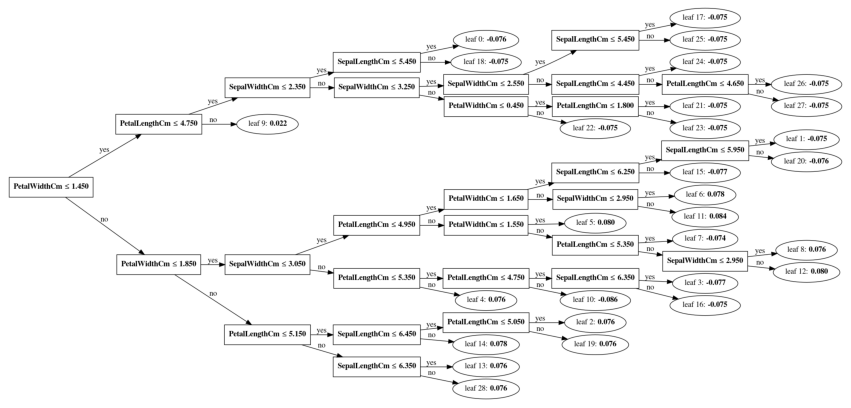

In [4]:
# plot the final tree
lgb.plot_tree(model, tree_index=len(tree_info)-1, figsize=(15, 10))

# 3. min_sum_hessian_in_leaf

In [5]:
# find the minimum leaf weight tree in existing model
min_leaf_weight = leaves['leaf_weight'].min()
min_leaf_weight

0.016927551478147507

In [6]:
# now set min_sum_hessian_in_leaf to .016, which is lower than the value we got from the previous cell
# no effect expected
param.update({'min_sum_hessian_in_leaf': .016})
model_test = lgb.train(param, trainSet)
_, leaves_test = grabtrees(model_test)
min_leaf_weight = leaves_test['leaf_weight'].min()
min_leaf_weight
# output confirms no change indeed

/opt/conda/lib/python3.7/site-packages/lightgbm/engine.py:148: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


0.016927551478147507

In [7]:
# next set min_sum_hessian_in_leaf to .018
# we do expect some clipping effects
param.update({'min_sum_hessian_in_leaf': .018})
model_test = lgb.train(param, trainSet)
tree_info_test, leaves_test = grabtrees(model_test)
min_leaf_weight = leaves_test['leaf_weight'].min()
min_leaf_weight
# output shows that min_leaf_weight is now higher as requested (more conservative)

0.01845717616379261

In [8]:
# next, try chopping more aggressively
param.update({'min_sum_hessian_in_leaf': .5})
model_test = lgb.train(param, trainSet)
tree_info_test, leaves_test = grabtrees(model_test)
min_leaf_weight = leaves_test['leaf_weight'].min()
min_leaf_weight
# voila, output as expected: this is how parameter *min_sum_hessian_in_leaf* gives us the full handle

0.5004193335771568

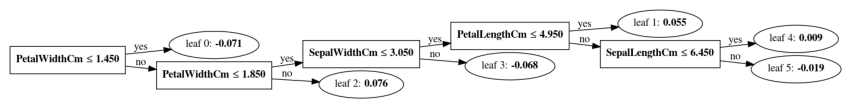

In [9]:
# plot and see
# we expect a tree far smaller than the original
lgb.plot_tree(model_test, tree_index=len(tree_info_test)-1, figsize=(15, 10))

# 4. Sister notebooks: the Leaf-by-leaf series
Decision trees: a leaf-by-leaf demo

https://www.kaggle.com/marychin/decision-trees-a-leaf-by-leaf-demo

**num_leaves** and **min_data_in_leaf**: a LightGBM demo

https://www.kaggle.com/marychin/num-leaves-min-data-in-leaf-a-lightgbm-demo

min_sum_hessian: a LightGBM demo (we are here)

https://www.kaggle.com/marychin/min-sum-hessian-a-lightgbm-demo

feature_importances split vs gain: a demo

https://www.kaggle.com/marychin/feature-importances-split-vs-gain-a-demo

# 5. Cheers, Kagglers & Kaggle!
Together we democratise learning and skills.